In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import save_image

import os

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 64
LATENT_DIM = 100
EPOCHS = 160
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_PATH = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = ImageFolder(root=DATA_PATH, transform=transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(2, LATENT_DIM)

        self.init_size = IMG_SIZE // 8   # important
        self.l1 = nn.Sequential(
            nn.Linear(LATENT_DIM, 128 * self.init_size * self.init_size)
        )

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 3, 3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        z = z + self.label_emb(labels)
        out = self.l1(z)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(2, IMG_SIZE * IMG_SIZE)

        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),   # 3 image channels + 1 label channel
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc = nn.Linear(512 * (IMG_SIZE // 16) * (IMG_SIZE // 16), 1)

    def forward(self, img, labels):
        label_map = self.label_emb(labels).view(labels.size(0), 1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([img, label_map], dim=1)   # concat as 4th channel

        out = self.model(x)
        out = out.view(out.size(0), -1)
        return torch.sigmoid(self.fc(out))

In [ ]:
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

In [ ]:
for epoch in range(EPOCHS):
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = imgs.size(0)

        valid = torch.ones(batch_size, 1).to(DEVICE)
        fake = torch.zeros(batch_size, 1).to(DEVICE)

        # Generator
        z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        gen_imgs = generator(z, labels)

        g_loss = criterion(discriminator(gen_imgs, labels), valid)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        # Discriminator
        real_loss = criterion(discriminator(imgs, labels), valid)
        fake_loss = criterion(discriminator(gen_imgs.detach(), labels), fake)

        d_loss = (real_loss + fake_loss) / 2

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

    print(f"Epoch {epoch} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 0 | D: 0.0576 | G: 3.7738
Epoch 1 | D: 0.0759 | G: 5.7281
Epoch 2 | D: 1.2644 | G: 15.9079
Epoch 3 | D: 0.0797 | G: 2.8810
Epoch 4 | D: 0.1314 | G: 9.5863
Epoch 5 | D: 0.0803 | G: 2.5528
Epoch 6 | D: 0.1646 | G: 5.9116
Epoch 7 | D: 0.0435 | G: 7.6751
Epoch 8 | D: 0.0522 | G: 2.5696
Epoch 9 | D: 0.1205 | G: 3.7117
Epoch 10 | D: 0.0742 | G: 2.9609
Epoch 11 | D: 0.1363 | G: 4.5281
Epoch 12 | D: 0.0287 | G: 3.5704
Epoch 13 | D: 0.0532 | G: 4.4786
Epoch 14 | D: 0.0368 | G: 4.1615
Epoch 15 | D: 0.0613 | G: 4.9138
Epoch 16 | D: 0.0321 | G: 3.3972
Epoch 17 | D: 0.0236 | G: 4.1063
Epoch 18 | D: 0.1112 | G: 1.8923
Epoch 19 | D: 0.0086 | G: 4.6556
Epoch 20 | D: 0.0107 | G: 11.5122
Epoch 21 | D: 0.0493 | G: 6.9146
Epoch 22 | D: 0.1412 | G: 4.9759
Epoch 23 | D: 0.0860 | G: 2.2482
Epoch 24 | D: 0.0089 | G: 7.3144
Epoch 25 | D: 0.0743 | G: 2.6063
Epoch 26 | D: 0.0117 | G: 6.2938
Epoch 27 | D: 0.0505 | G: 2.9388
Epoch 28 | D: 0.0254 | G: 5.9367
Epoch 29 | D: 0.0223 | G: 3.6770
Epoch 30 | D: 0.39

In [ ]:
GEN_DIR = "/content/drive/MyDrive/TongueImagediabetes/generated_dcgan"
os.makedirs(GEN_DIR, exist_ok=True)

generator.eval()
with torch.no_grad():
    for class_label in [0, 1]:
        z = torch.randn(200, LATENT_DIM).to(DEVICE)
        labels = torch.full((200,), class_label, dtype=torch.long).to(DEVICE)

        gen_imgs = generator(z, labels)
        gen_imgs = (gen_imgs + 1) / 2

        for i in range(200):
            save_image(gen_imgs[i], f"{GEN_DIR}/class{class_label}_{i}.png")

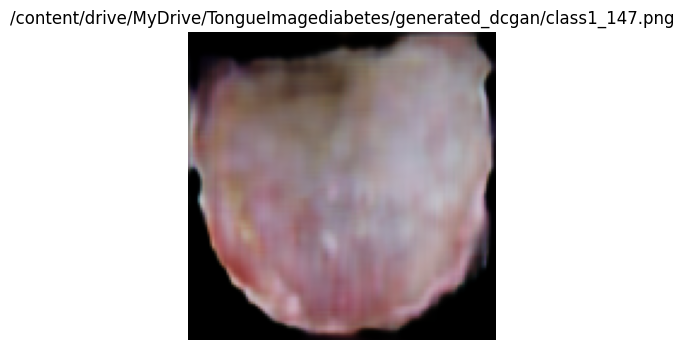

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

sample_path = os.path.join(GEN_DIR, random.choice(os.listdir(GEN_DIR)))
img = Image.open(sample_path)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis("off")
plt.title(sample_path)
plt.show()

In [ ]:
import pandas as pd
import os

GEN_DIR = "/content/drive/MyDrive/TongueImagediabetes/generated_dcgan"

rows = []

for fname in os.listdir(GEN_DIR):
    if fname.endswith(".png"):
        path = os.path.join(GEN_DIR, fname)

        if "class0" in fname:
            label = 0
        else:
            label = 1

        rows.append({
            "image_path": path,
            "label": label
        })

syn_df = pd.DataFrame(rows)

print("Synthetic samples:", len(syn_df))
print(syn_df["label"].value_counts())

Synthetic samples: 400
label
0    200
1    200
Name: count, dtype: int64


In [ ]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

SEED = 42

BASE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb"

rows = []

for p in Path(BASE_DIR + "/diabetes").glob("*"):
    if p.suffix.lower() in [".png", ".jpg", ".jpeg"]:
        rows.append({"image_path": str(p), "label": 1})

for p in Path(BASE_DIR + "/nondiabetes").glob("*"):
    if p.suffix.lower() in [".png", ".jpg", ".jpeg"]:
        rows.append({"image_path": str(p), "label": 0})

df = pd.DataFrame(rows)

train_df, _ = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)

print("Train samples:", len(train_df))

Train samples: 667


In [ ]:
aug_train_df = pd.concat([train_df, syn_df]).reset_index(drop=True)

print("Original:", len(train_df))
print("Augmented:", len(aug_train_df))

Original: 667
Augmented: 1067
